In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Dataset

Run the cell given below to generate the data-matrix $\mathbf{X}$, which is of shape $(n, d)$, where $n$ denotes the number of samples and $d$ denotes the number of features.

**Do not edit this cell.**

In [3]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=50, n_features=2, n_informative = 2, n_redundant = 0, n_clusters_per_class = 1, flip_y = 0, class_sep = 3, random_state=20)

## Problem 1
How many samples are there in the dataset?



In [4]:
X.shape[0]

50

## Problem 2

How many features are there in the dataset?


In [5]:
X.shape[1]

2

## Problem 3
In the target vector $y$, replace all occurrences of 0 with -1.

How many unique classes are there in the target vector?



In [6]:
y[y==0] = -1
print(len(np.unique(y)))

2


## Problem 4
Plot the data keepig first feature on the x-axis and the second feature on the y-axis. Plot the data points belonging to each class in different colors. Does the data seem linearly separable?

[MCQ]

**Options:**

(a) Yes

(b) No



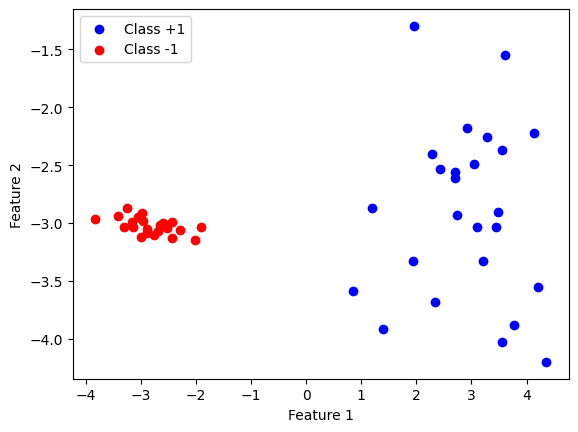

In [8]:
plt.scatter(X[y==1 , 0] , X[y==1 , 1] , color='blue' , label='Class +1')
plt.scatter(X[y==-1 , 0] , X[y==-1 , 1] , color='red' , label='Class -1')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

## Problem 5

Initialize $w$ to be a zero vector, with shape equal to the number of features in the data.

Iterate over each data point $x$ in $X$ one by one (in the same sequence as present in $X$). For each data point, compute the value of $w^T x$. If $w^T x \ge 0$, predict positive class for $x$, else predict the negative class.

If prediction does not match the actual class label, update the weight vector as per the following update rule:
$$
w_{\text{new}} = w_{\text{old}} + x y
$$
where $x$ is the data point and $y$ is the actual label of $x$.

Run the above for 10 epochs (iterations), but stop if there are no weight updates in an epoch.

In which iteration does the number of weight updates become zero for the first time?

[NAT]

**Options**

(a) 1  

(b) 2  

(c) 3  

(d) 5  

In [13]:
w = np.zeros(X.shape[1])

for epoch in range(1,11):

    updates=0
    
    for i in range(len(X)):
    
        x_i = X[i]
        y_i = y[i]
    
        if np.dot(w,x_i)>=0:
            y_pred=1
        else:
            y_pred=-1

        if y_pred != y_i:
            w = w + x_i*y_i
            updates+=1
    
    print(f"Epoch {epoch} : {updates} updates")

    if updates==0:
        print(f"Epoch Stopped at {epoch}")
        break





Epoch 1 : 2 updates
Epoch 2 : 0 updates
Epoch Stopped at 2


## Problem 6
Plot the vector w and the decision boundary thus obtained.



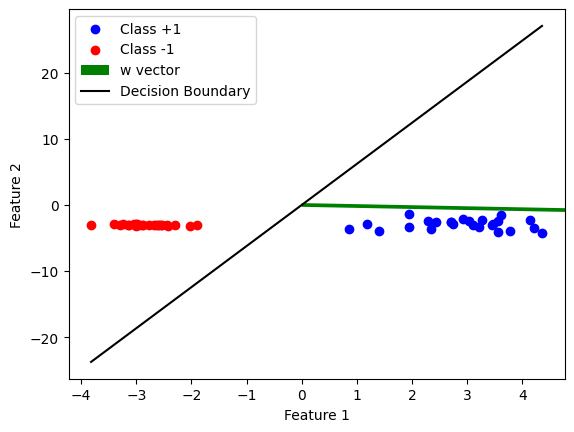

In [14]:
# --- Data points plot karo (Problem 4 wala) ---
plt.scatter(X[y==1, 0],  X[y==1, 1],  color='blue', label='Class +1')
plt.scatter(X[y==-1, 0], X[y==-1, 1], color='red',  label='Class -1')

# --- W vector plot karo (origin se arrow) ---
plt.quiver(0, 0, w[0], w[1],
           color='green',
           scale=1,
           scale_units='xy',
           angles='xy',
           label='w vector')

# --- Decision boundary plot karo ---
x1_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)
#          ↑ x-axis pe points banao (min se max tak)

x2_vals = -(w[0]/w[1]) * x1_vals
#          ↑ formula se y values nikalo

plt.plot(x1_vals, x2_vals, color='black', label='Decision Boundary')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

## Problem 7
What is the value of loss using the weight vector obtained earlier?  


In [15]:
total_loss = 0

for i in range(len(X)):
    # prediction karo
    if np.dot(w, X[i]) >= 0:
        y_pred = 1
    else:
        y_pred = -1
    
    # galat hua toh loss badhao
    if y_pred != y[i]:
        total_loss += 1

print("Loss =", total_loss)

Loss = 0


## Problem 8
Now use the following data set, replace occurrences of 0 with -1 and visualize.

**Do not edit the following cell.**



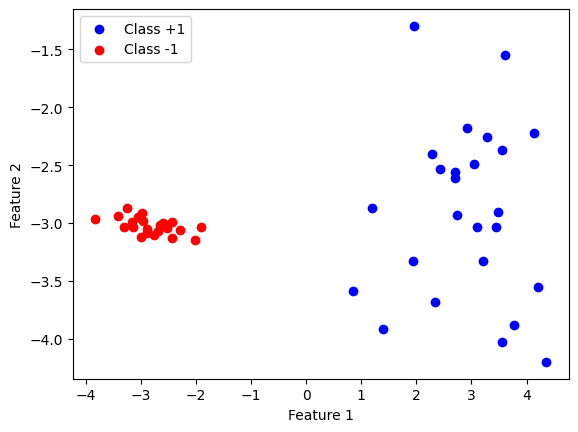

In [16]:
# Naya dataset already generate ho gaya upar wale cell se
# (make_classification wala)

# Step 1: 0 ko -1 se replace karo (Problem 3 jaisa)
y[y == 0] = -1

# Step 2: Plot karo (Problem 4 jaisa)
plt.scatter(X[y==1, 0],  X[y==1, 1],  color='blue', label='Class +1')
plt.scatter(X[y==-1, 0], X[y==-1, 1], color='red',  label='Class -1')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

## Problem 9

Apply the Perceptron code again.

What is the number of weight updates performed in epoch 10?



In [17]:
w = np.zeros(X.shape[1])  # w reset karo naye dataset ke liye

for epoch in range(1, 11):          # 10 epochs
    updates = 0

    for i in range(len(X)):
        x_i = X[i]
        y_i = y[i]

        if np.dot(w, x_i) >= 0:
            y_pred = 1
        else:
            y_pred = -1

        if y_pred != y_i:
            w = w + x_i * y_i
            updates += 1

    print(f"Epoch {epoch}: {updates} updates")

    # DHYAN RAK - ab break mat karo!
    # problem 9 mein epoch 10 tak ZAROOR chalana hai

Epoch 1: 2 updates
Epoch 2: 0 updates
Epoch 3: 0 updates
Epoch 4: 0 updates
Epoch 5: 0 updates
Epoch 6: 0 updates
Epoch 7: 0 updates
Epoch 8: 0 updates
Epoch 9: 0 updates
Epoch 10: 0 updates


## Problem 10
Visualize the weight vector and the decision boundary.



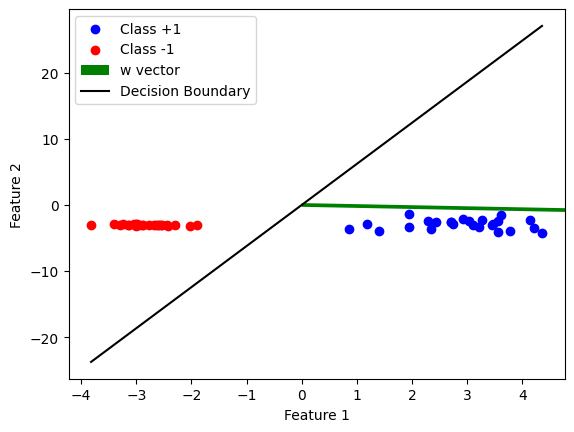

In [18]:
# --- Data points plot karo ---
plt.scatter(X[y==1, 0],  X[y==1, 1],  color='blue', label='Class +1')
plt.scatter(X[y==-1, 0], X[y==-1, 1], color='red',  label='Class -1')

# --- W vector plot karo ---
plt.quiver(0, 0, w[0], w[1],
           color='green',
           scale=1,
           scale_units='xy',
           angles='xy',
           label='w vector')

# --- Decision boundary plot karo ---
x1_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)
x2_vals = -(w[0]/w[1]) * x1_vals

plt.plot(x1_vals, x2_vals, color='black', label='Decision Boundary')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

## Problem 11
What is the value of loss using the weight vector obtained in the 10th epoch?

In [19]:
# Problem 7 wala same code
y_pred = np.where(np.dot(X, w) >= 0, 1, -1)

loss = np.sum(y_pred != y)

print("Loss =", loss)

Loss = 0
